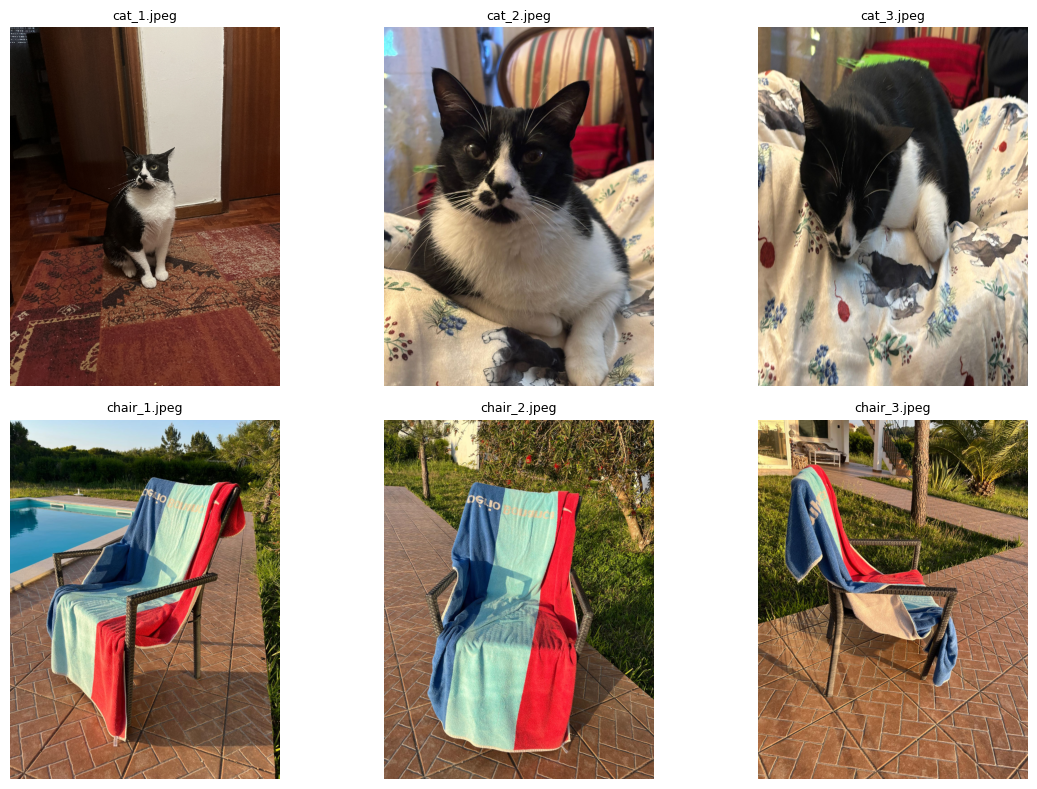

In [22]:
import os
import matplotlib.pyplot as plt
import cv2 as cv 

test_dir = './test_images'

# Path to new sets of images
image_set_1_dir = os.path.join(test_dir, 'image_set_1')
image_set_2_dir = os.path.join(test_dir, 'image_set_2')
image_set_3_dir = os.path.join(test_dir, 'image_set_3')

# Read the images in RGB to display & in grayscale for FAST keypoint detection
img_dict = {}
for img_name in sorted(os.listdir((image_set_3_dir))):
    if img_name.startswith('.'):
        continue
    path = os.path.join(image_set_3_dir, img_name)

    # Read RGB
    img = cv.imread(path, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (600, 800)) # Resize to avoid long computation time
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Convert BGR (OpenCV default) to RGB for matplotlib
    img_dict[img_name] = img_rgb # Associate filename with respective image

# Plot
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs = axs.flatten()  # Flatten to 1D list

for ax, (img_name, img) in zip(axs, img_dict.items()):
    ax.imshow(img)
    ax.set_title(img_name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image
import torch
from torchvision import transforms
import clip  # OpenAI's clip package
import sys

test_dir = './test_images'

# Path to new sets of images
image_set_1_dir = os.path.join(test_dir, 'image_set_1')
image_set_2_dir = os.path.join(test_dir, 'image_set_2')
image_set_3_dir = os.path.join(test_dir, 'image_set_3')


def load_and_preprocess_images(image_folder, model_name='ViT-B/16', device='cuda' if torch.cuda.is_available() else 'cpu'):
    model, preprocess = clip.load(model_name, device=device)

    image_paths = []
    image_tensors = []

    for filename in os.listdir(image_folder):
        if filename.startswith('.'):
            continue
        path = os.path.join(image_folder, filename)
        if not os.path.isfile(path):
            continue
        try:
            image = Image.open(path).convert("RGB")
            tensor = preprocess(image)
            image_paths.append(path)
            image_tensors.append(tensor)
        except Exception as e:
            print(f"Skipping file {filename}: {e}")

    if not image_tensors:
        print("No valid images found.")
        sys.exit(1)

    image_batch = torch.stack(image_tensors).to(device)

    return image_paths, image_batch


In [4]:
import torch
import clip

def filter_images(image_folder, prompt, model_name='ViT-B/16', similarity_threshold=0.25):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model, _ = clip.load(model_name, device=device)

    image_paths, image_batch = load_and_preprocess_images(image_folder, model_name, device)

    with torch.no_grad():
        text_tokens = clip.tokenize([prompt]).to(device)
        text_features = model.encode_text(text_tokens).float()
        image_features = model.encode_image(image_batch).float()

        # Normalize
        text_features /= text_features.norm(dim=-1, keepdim=True)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # Compute similarity
        similarities = (image_features @ text_features.T).squeeze()

    # Filter based on threshold
    kept_images = [(path, score.item()) for path, score in zip(image_paths, similarities) if score >= similarity_threshold]

    print(f"\nImages matching '{prompt}':")
    for path, score in kept_images:
        print(f"{path} (similarity: {score:.3f})")

    return kept_images

import sys

image_folder = image_set_3_dir
prompt = 'cat'

filter_images(image_folder, prompt)


100%|███████████████████████████████████████| 335M/335M [00:46<00:00, 7.51MiB/s]


Skipping file .DS_Store: cannot identify image file './test_images/image_set_3/.DS_Store'

Images matching 'cat':
./test_images/image_set_3/cat_1.jpeg (similarity: 0.287)
./test_images/image_set_3/cat_3.jpeg (similarity: 0.262)


[('./test_images/image_set_3/cat_1.jpeg', 0.2866019606590271),
 ('./test_images/image_set_3/cat_3.jpeg', 0.26161229610443115)]

In [18]:
import os
import cv2 as cv
import numpy as np
from PIL import Image
from itertools import combinations
import torch
import open_clip
from torchvision import transforms
from sentence_transformers import util
import pandas as pd

def filter_images_semantic_visual(
    image_folder,
    prompt="cat",
    model_name="ViT-B-16-plus-240",
    pretrained="laion400m_e32",
    device=None,
    prompt_similarity_threshold=0.2,
    cluster_similarity_threshold=60.0
):
    device = device or ("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

    # Load model and preprocess
    model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
    model.to(device)
    model.eval()

    # Tokenize prompt
    with torch.no_grad():
        text_tokens = open_clip.tokenize([prompt]).to(device)
        text_features = model.encode_text(text_tokens).float()
        text_features /= text_features.norm(dim=-1, keepdim=True)

    # Load and preprocess images
    image_dict = {}
    image_features = []
    image_paths = []

    for fname in sorted(os.listdir(image_folder)):
        if fname.startswith('.'):
            continue
        path = os.path.join(image_folder, fname)
        try:
            img = Image.open(path).convert("RGB")
            tensor = preprocess(img).unsqueeze(0).to(device)

            with torch.no_grad():
                feat = model.encode_image(tensor).float()
                feat /= feat.norm(dim=-1, keepdim=True)

            similarity = (feat @ text_features.T).item()
            if similarity >= prompt_similarity_threshold:
                image_dict[fname] = cv.imread(path, cv.IMREAD_UNCHANGED)
                image_features.append(feat)
                image_paths.append(fname)
                print(f"Keeping (text): {fname} - similarity: {similarity:.3f}")
            else:
                print(f"Filtered (text): {fname} - similarity: {similarity:.3f}")
        except Exception as e:
            print(f"Skipped {fname}: {e}")

    # If only 1 image matches, return early
    if len(image_dict) <= 1:
        return list(image_dict.keys())

    # Compute image-to-image similarity
    filtered = []
    for (name1, img1), (name2, img2) in combinations(image_dict.items(), 2):
        emb1 = encode_image(img1, model, preprocess, device)
        emb2 = encode_image(img2, model, preprocess, device)
        score = util.pytorch_cos_sim(emb1, emb2).item() * 100
        print(f"Pair {name1} <-> {name2} similarity: {score:.2f}")

        if score >= cluster_similarity_threshold:
            filtered.append(name1)
            filtered.append(name2)

    # Return unique names that passed both filters
    final_images = sorted(set(filtered))
    print(f"\nFinal selected images: {final_images}")
    return final_images


def encode_image(img_array, model, preprocess, device):
    image = Image.fromarray(img_array).convert("RGB")
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model.encode_image(tensor).float()
        feat /= feat.norm(dim=-1, keepdim=True)
    return feat


image_folder = image_set_3_dir
selected = filter_images_semantic_visual(image_folder, prompt="cat sleeping")

Keeping (text): cat_1.jpeg - similarity: 0.267
Filtered (text): cat_2.jpeg - similarity: 0.179
Keeping (text): cat_3.jpeg - similarity: 0.300
Filtered (text): chair_1.jpeg - similarity: 0.060
Filtered (text): chair_2.jpeg - similarity: 0.056
Filtered (text): chair_3.jpeg - similarity: 0.096
Pair cat_1.jpeg <-> cat_3.jpeg similarity: 61.23

Final selected images: ['cat_1.jpeg', 'cat_3.jpeg']


In [8]:
for img_name in os.listdir(image_set_3_dir):
    print(img_name)

chair_3.jpeg
.DS_Store
chair_2.jpeg
cat_1.jpeg
cat_2.jpeg
cat_3.jpeg
chair_1.jpeg


In [53]:
os.path.expanduser('~/')

'/Users/franco/'

In [36]:
def compute_pairwise_clip_similarity(
    image_folder,
    model_name="ViT-B-16-plus-240",
    pretrained="laion400m_e32",
    device=None,
):
    device = device or ("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

    # Load model and preprocessing
    model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
    model.to(device)
    model.eval()

    # Load and encode images
    image_features = {}
    for fname in sorted(os.listdir(image_folder)):
        if fname.startswith('.'):
            continue
        path = os.path.join(image_folder, fname)
        try:
            img = Image.open(path).convert("RGB")
            tensor = preprocess(img).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = model.encode_image(tensor).float()
                feat /= feat.norm(dim=-1, keepdim=True)
            image_features[fname] = feat
        except Exception as e:
            print(f"Error reading {fname}: {e}")

    # Compute pairwise similarities
    similarity_data = []
    for (name1, feat1), (name2, feat2) in combinations(image_features.items(), 2):
        sim = util.pytorch_cos_sim(feat1, feat2).item() * 100
        similarity_data.append((name1, name2, round(sim, 2)))

    # Create and return dataframe
    df = pd.DataFrame(similarity_data, columns=["Image1", "Image2", "Similarity"])
    df.sort_values("Similarity", ascending=False, inplace=True)
    return df

df_sim = compute_pairwise_clip_similarity(image_set_3_dir)


import networkx as nx
import community as community_louvain
import pandas as pd

def run_louvain_clustering(df_sim, similarity_column='Similarity', threshold=0.0):
    """
    Given a similarity dataframe with columns ['Image1', 'Image2', 'Similarity'],
    builds a weighted graph and applies Louvain clustering.

    Parameters:
        df_sim: pd.DataFrame
            DataFrame with pairwise similarities.
        similarity_column: str
            Column name for similarity scores.
        threshold: float
            Minimum similarity required to consider an edge in the graph.

    Returns:
        cluster_df: pd.DataFrame
            DataFrame mapping image names to detected communities.
    """
    # Step 1: Build graph
    G = nx.Graph()
    for _, row in df_sim.iterrows():
        if row[similarity_column] >= threshold:
            G.add_edge(row['Image1'], row['Image2'], weight=row[similarity_column])

    # Step 2: Run Louvain community detection
    partition = community_louvain.best_partition(G, weight='weight')

    # Step 3: Convert to DataFrame
    cluster_df = pd.DataFrame(list(partition.items()), columns=['Node', 'Community'])
    cluster_df = cluster_df.sort_values(by='Node').reset_index(drop=True)
    return cluster_df

# After computing df_sim
cluster_df = run_louvain_clustering(df_sim, threshold=60.0)
cluster_df

,Node,Community
0,cat_1.jpeg,0
1,cat_2.jpeg,0
2,cat_3.jpeg,0
3,chair_1.jpeg,1
4,chair_2.jpeg,1
5,chair_3.jpeg,1


In [45]:
def select_cluster_by_prompt(
    cluster_df,
    image_folder,
    prompt,
    model_name="ViT-B-16-plus-240",
    pretrained="laion400m_e32",
    device=None
):
    """
    Selects a cluster matching the user's prompt using CLIP similarity,
    but only if multiple clusters have equal size.

    Parameters:
        cluster_df: pd.DataFrame with ['Node', 'Community']
        image_folder: Path to images
        prompt: User-provided text (e.g., "cat")
        model_name, pretrained, device: CLIP model settings

    Returns:
        selected_images: List of filenames belonging to the selected cluster
    """
    from PIL import Image
    import open_clip
    import torch

    device = device or ("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

    # Get image groups by cluster
    cluster_groups = cluster_df.groupby("Community")["Node"].apply(list).to_dict()
    sizes = [len(v) for v in cluster_groups.values()]

    if len(set(sizes)) == 1:  # All clusters are equal-sized
        # Load model
        model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
        model.to(device)
        model.eval()

        # Encode prompt
        with torch.no_grad():
            text_tokens = open_clip.tokenize([prompt]).to(device)
            text_feat = model.encode_text(text_tokens).float()
            text_feat /= text_feat.norm(dim=-1, keepdim=True)

        best_cluster = None
        best_score = -float("inf")

        for cid, nodes in cluster_groups.items():
            scores = []
            for fname in nodes:
                path = os.path.join(image_folder, fname)
                try:
                    img = Image.open(path).convert("RGB")
                    tensor = preprocess(img).unsqueeze(0).to(device)
                    with torch.no_grad():
                        img_feat = model.encode_image(tensor).float()
                        img_feat /= img_feat.norm(dim=-1, keepdim=True)
                        score = (img_feat @ text_feat.T).item()
                        scores.append(score)
                except Exception as e:
                    print(f"Error processing {fname}: {e}")
            avg_score = sum(scores) / len(scores) if scores else -1
            if avg_score > best_score:
                best_score = avg_score
                best_cluster = cid

        selected_images = cluster_groups[best_cluster]
        print(f"Selected cluster: {best_cluster}, Avg similarity: {best_score:.3f}")
        return selected_images

    else:
        # Return largest cluster (or define your own logic)
        max_cluster = max(cluster_groups.items(), key=lambda kv: len(kv[1]))[0]
        print(f"Selected cluster (largest): {max_cluster}")
        return cluster_groups[max_cluster]


final_selection = select_cluster_by_prompt(
    cluster_df,
    image_folder=image_set_3_dir,
    prompt="black and white cat"
)
print("Final selected images:", final_selection)

Selected cluster (largest): 0
Final selected images: ['bibimbap-gf29abdbf1_640.jpg', 'champon-g31fa88e14_640.jpg', 'chicken-soup-g76231cf36_640.jpg', 'fried-rice-g8b4a54246_640.jpg', 'hamburger-gafdf3eadc_640.jpg', 'mandu-g79128b0db_640.jpg', 'octopus-desktop-gab5dc2902_640.jpg', 'salad-bar-g5de038197_640.jpg', 'sushi-g108a16441_640.jpg', 'sushi-g47b8ca32e_640.jpg']


In [32]:
image_set_3_dir

'./test_images/image_set_3'

In [39]:
ultimate_test = './test_images/photos_no_class'

df_sim = compute_pairwise_clip_similarity(ultimate_test)
df_sim

,Image1,Image2,Similarity
3132,sushi-g108a16441_640.jpg,sushi-g47b8ca32e_640.jpg,85.63
235,cat-g0052cc4e9_640.jpg,cat-g11b1f4535_640.jpg,82.97
2990,puppy-g0235e261e_640.jpg,puppy-ge9d742e37_640.jpg,82.29
985,champon-g31fa88e14_640.jpg,mandu-g79128b0db_640.jpg,80.99
845,cat-gf324dae69_640.jpg,kitten-gfa0ebce93_640.jpg,78.88
...,...,...,...
2537,mama-gc2e107d95_640.jpg,nem-gdf1e9c93c_640.jpg,8.97
966,champon-g31fa88e14_640.jpg,father-g7328a944c_640.jpg,8.58
1571,family-g2ea85c1e0_640.jpg,father-g7328a944c_640.jpg,8.11
2007,father-g7328a944c_640.jpg,pasta-ge05c4d3a5_640.jpg,8.10


In [47]:
cluster_df = run_louvain_clustering(df_sim, threshold=60.0)
cluster_df.sort_values('Community').groupby('Community', as_index=0)['Node'].count()

,Community,Node
0,0,10
1,1,10
2,2,10
3,3,2
4,4,2
5,5,2
6,6,2
7,7,2
8,8,2
9,9,2


In [44]:
final_selection = select_cluster_by_prompt(
    cluster_df,
    image_folder=ultimate_test,
    prompt="cat"
)
print("Final selected images:", final_selection)

Selected cluster (largest): 0
Final selected images: ['bibimbap-gf29abdbf1_640.jpg', 'champon-g31fa88e14_640.jpg', 'chicken-soup-g76231cf36_640.jpg', 'fried-rice-g8b4a54246_640.jpg', 'hamburger-gafdf3eadc_640.jpg', 'mandu-g79128b0db_640.jpg', 'octopus-desktop-gab5dc2902_640.jpg', 'salad-bar-g5de038197_640.jpg', 'sushi-g108a16441_640.jpg', 'sushi-g47b8ca32e_640.jpg']
